In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv"
df = pd.read_csv(url)
df.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


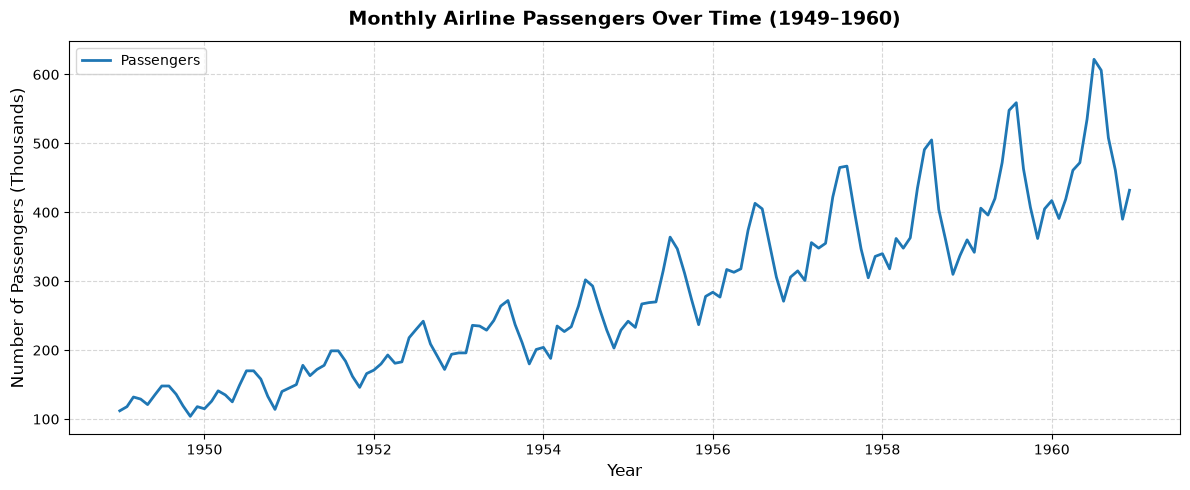

In [3]:
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'], format='%Y-%B')
df = df.sort_values('date').reset_index(drop=True)


plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['passengers'], color='#1f77b4', linewidth=2, label='Passengers')

plt.title('Monthly Airline Passengers Over Time (1949–1960)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers (Thousands)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

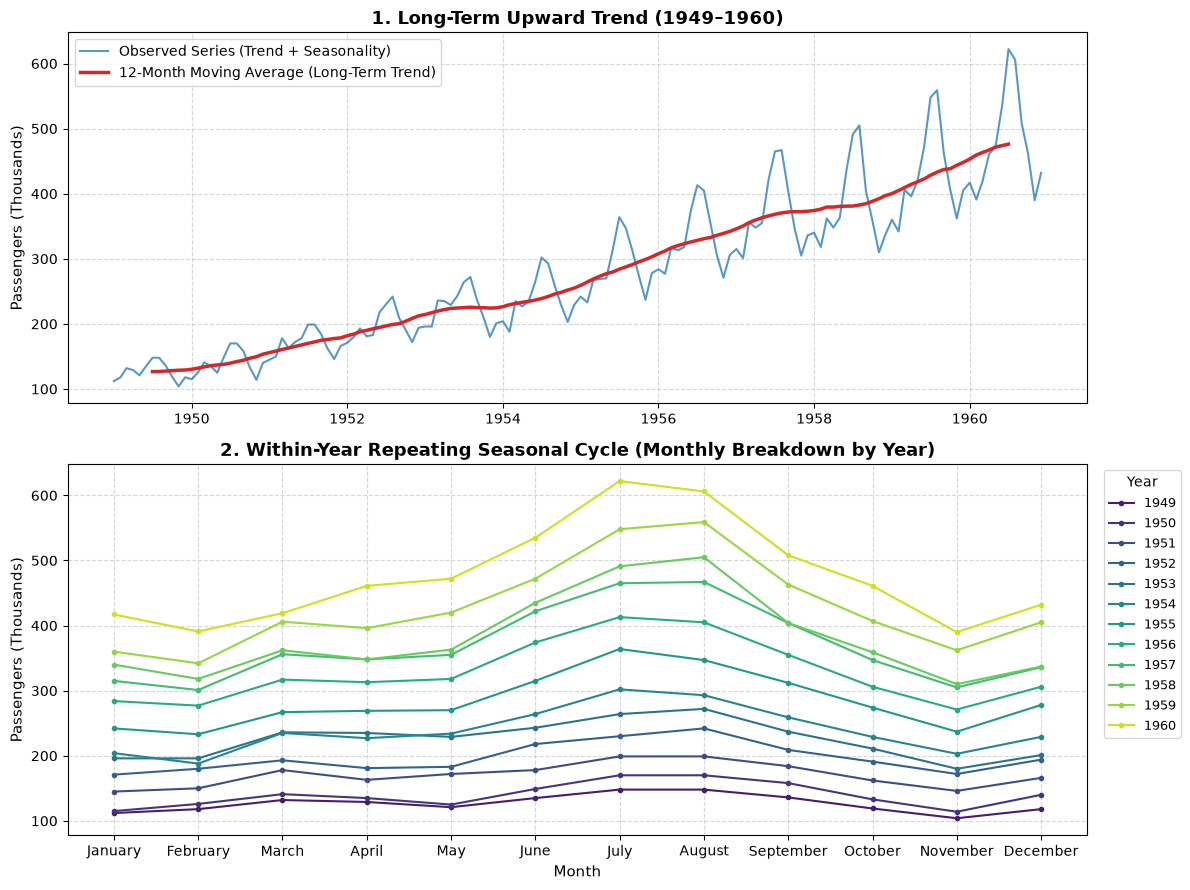

In [4]:

df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'], format='%Y-%B')
df = df.sort_values('date').reset_index(drop=True)

# 3. Calculate 12-month moving average to smooth out seasonality and extract the long-term trend
df['12M_MA'] = df['passengers'].rolling(window=12, center=True).mean()

# 4. Construct dual-panel plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

# --- PANEL 1: Long-Term Rise (Trend + Seasonality) ---
ax1.plot(df['date'], df['passengers'], label='Observed Series (Trend + Seasonality)', color='#1f77b4', alpha=0.75, linewidth=1.5)
ax1.plot(df['date'], df['12M_MA'], label='12-Month Moving Average (Long-Term Trend)', color='#d62728', linewidth=2.5)
ax1.set_title('1. Long-Term Upward Trend (1949–1960)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Passengers (Thousands)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# --- PANEL 2: Within-Year Repeating Cycle (Seasonal Overlay) ---
years = df['year'].unique()
palette = sns.color_palette("viridis", n_colors=len(years))

for idx, yr in enumerate(years):
    sub = df[df['year'] == yr]
    ax2.plot(sub['month'], sub['passengers'], marker='o', markersize=3, label=str(yr), color=palette[idx], linewidth=1.5)

ax2.set_title('2. Within-Year Repeating Seasonal Cycle (Monthly Breakdown by Year)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Passengers (Thousands)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

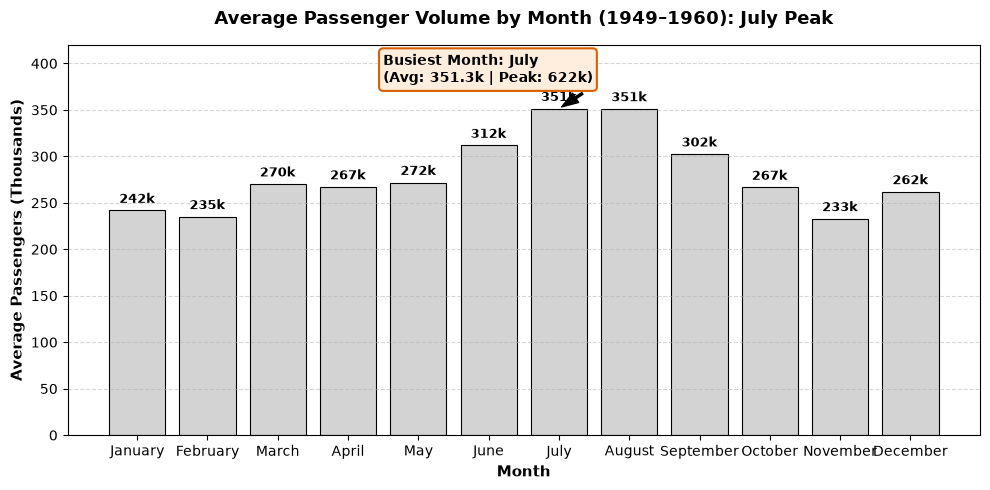

In [5]:

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
monthly_avg = df.groupby('month', observed=False)['passengers'].mean().reset_index()

# 3. Define color hierarchy (Highlight July & August, mute remaining months)
colors = ['#d3d3d3' if m not in ['Jul', 'Aug'] else ('#d95f02' if m == 'Jul' else '#fdbf6f') 
          for m in monthly_avg['month']]

plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_avg['month'], monthly_avg['passengers'], color=colors, edgecolor='black', linewidth=0.8)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{yval:.0f}k', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.annotate('Busiest Month: July\n(Avg: 351.3k | Peak: 622k)', 
             xy=(6, 351.3), xytext=(3.5, 380),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#ffeedd", ec="#d95f02", lw=1.5))

plt.title('Average Passenger Volume by Month (1949–1960): July Peak', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11, fontweight='bold')
plt.ylabel('Average Passengers (Thousands)', fontsize=11, fontweight='bold')
plt.ylim(0, 420)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()